# Cook Like a Quant Researcher: A Review of Python for Algorithmic Trading Cookbook


<a href="https://www.kaggle.com/code/addarm/algorithmic_trading_cookbook_review" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

![algorithmic trading cookbook banner 2026.08.13](https://raw.githubusercontent.com/adamd1985/quant_research/main/images/algorithmic_trading_cookbook_review_banner.png)

<!-- @import "[TOC]" {cmd="toc" depthFrom=1 depthTo=6 orderedList=false} -->

We got access to the second edition of [*Python for Algorithmic Trading Cookbook*](https://www.packtpub.com/en-us/product/python-for-algorithmic-trading-cookbook-9781806662036), a broad tour of a modern quant developer's workbench. A solo researcher could spend months assembling the same collection of tools independently. The book also gives retail traders a practical route into capital markets using tools close to those used in industry. Close is the key word.

That breadth matters most for retail readers. The book puts DataFrames, Polars, DuckDB, ArcticDB, VectorBT, Zipline, factor diagnostics, and LLM workflows in one place. Most recipes are accessible enough to reproduce without an institutional data platform or engineering team.

The book also promises rigorous evaluation, protection against look-ahead bias, and production-quality trading applications. In our opinion, those claims demand more than runnable code. This article reviews the book's main examples, keeps the parts that teach well, and repairs the places where the evidence or implementation falls short.

The empirical sections use real monthly adjusted prices for 110 current US stocks from 2005 through 2025 and real Fama-French factors. Because today's surviving stocks determine the historical universe, the sample contains survivorship bias. We accept that limitation to keep the examples readable, and we do not treat these results as investable evidence.


## Setup

The setup prepares the full dataset. On the first run, it creates the `data` directory and downloads monthly adjusted prices, the stock universe, and Fama-French factors.


In [1]:
%%capture
%pip install statsmodels==0.14.6 --no-deps


In [2]:
import numpy as np
import pandas as pd
import io
import ast
import zipfile
from pathlib import Path
from urllib.request import urlopen

import matplotlib.pyplot as plt
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
import scipy
import sklearn
import statsmodels


plt.style.use("seaborn-v0_8-whitegrid")
rng = np.random.default_rng(42)

PRICE_URL = (
    "https://raw.githubusercontent.com/HerdingAI/stock-price-returns/e58de84b37a85d6c0fb95cad4f52146fc4f0cb97/output/monthly_prices.csv"
)
UNIVERSE_URL = (
    "https://raw.githubusercontent.com/HerdingAI/stock-price-returns/e58de84b37a85d6c0fb95cad4f52146fc4f0cb97/output/universe.csv"
)
FACTOR_URL = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_CSV.zip"


print(f"numpy {np.__version__}, pandas {pd.__version__}")
print(f"scipy {scipy.__version__}, scikit-learn {sklearn.__version__}, statsmodels {statsmodels.__version__}")

numpy 2.5.2, pandas 3.0.5
scipy 1.18.0, scikit-learn 1.5.1, statsmodels 0.14.6


In [3]:
# Cache each external source so later cells use one fixed local copy.
DATA_DIRECTORY = Path("data")
PRICE_FILE = DATA_DIRECTORY / "market_monthly_prices.csv"
UNIVERSE_FILE = DATA_DIRECTORY / "market_universe.csv"
FACTOR_FILE = DATA_DIRECTORY / "fama_french_3_factors.csv"
DATA_DIRECTORY.mkdir(exist_ok=True)

if not PRICE_FILE.exists():
    pd.read_csv(PRICE_URL).to_csv(PRICE_FILE, index=False)
if not UNIVERSE_FILE.exists():
    pd.read_csv(UNIVERSE_URL).to_csv(UNIVERSE_FILE, index=False)
if not FACTOR_FILE.exists():
    with urlopen(FACTOR_URL) as response:
        archive = zipfile.ZipFile(io.BytesIO(response.read()))
        factor_text = archive.read(archive.namelist()[0]).decode("utf-8")
        FACTOR_FILE.write_text(factor_text, encoding="utf-8")

# Print a small manifest so the reader can verify what was prepared.
prepared_files = pd.DataFrame(
    {
        "file": [PRICE_FILE, UNIVERSE_FILE, FACTOR_FILE],
        "contents": [
            "monthly adjusted prices",
            "security classifications",
            "monthly market, size, value, and risk-free factors",
        ],
    }
)
prepared_files["size_kb"] = prepared_files["file"].map(lambda path: path.stat().st_size / 1024 if path.exists() else 0)

assert prepared_files["size_kb"].gt(0).all()

print(prepared_files.to_string(index=False, formatters={"size_kb": "{:.1f}".format}))


                          file                                           contents size_kb
data\market_monthly_prices.csv                            monthly adjusted prices  2250.2
      data\market_universe.csv                           security classifications    29.9
data\fama_french_3_factors.csv monthly market, size, value, and risk-free factors    52.5


In [4]:
# Load the cached files and form one stock-by-month price table.
all_prices = pd.read_csv(PRICE_FILE, index_col="Date", parse_dates=True)
universe = pd.read_csv(UNIVERSE_FILE)

stock_tickers = universe.loc[
    (universe["asset_class"] == "Equity (single stock)") & universe["present"],
    "ticker",
]

# Keep a common date range, then drop stocks with missing months.
analysis_prices = all_prices.loc["2005-01-31":"2025-12-31", stock_tickers]
prices = analysis_prices.dropna(axis=1)
returns = prices.pct_change(fill_method=None).dropna()
spy_prices = all_prices.loc[prices.index, "SPY"]
spy_returns = spy_prices.pct_change(fill_method=None).dropna()

assert prices.shape == (252, 110)
assert not prices.isna().any().any()

print("Source: Yahoo Finance adjusted monthly prices via HerdingAI")
print(f"Sample: {prices.index.min():%Y-%m} to {prices.index.max():%Y-%m}")
print(f"Stock-by-month table: {prices.shape[1]} current US stocks and {prices.shape[0]} months")
print("Use: educational method demonstrations; the current-stock universe has survivorship bias")
panel_excerpt = returns.loc[
    "2025-07-31":"2025-12-31",
    ["AAPL", "MSFT", "JPM", "XOM", "JNJ"],
]
print()
print("Monthly-return table excerpt")
print(panel_excerpt.map(lambda value: f"{value:.1%}").to_string())


Source: Yahoo Finance adjusted monthly prices via HerdingAI
Sample: 2005-01 to 2025-12
Stock-by-month table: 110 current US stocks and 252 months
Use: educational method demonstrations; the current-stock universe has survivorship bias

Monthly-return table excerpt
             AAPL   MSFT    JPM    XOM    JNJ
Date                                         
2025-07-31   1.2%   7.3%   2.7%   3.6%   7.8%
2025-08-31  12.0%  -4.9%   1.7%   3.3%   8.3%
2025-09-30   9.7%   2.2%   4.6%  -1.3%   4.7%
2025-10-31   6.2%  -0.0%  -0.9%   1.4%   1.9%
2025-11-30   3.2%  -4.8%   0.6%   2.3%  10.3%
2025-12-31  -2.5%  -1.7%   2.9%   3.8%   0.0%


The table has one row per month and one column per stock. July 2025 is one shared market environment across five companies; the AAPL column follows one company through six months. This layout is often called a stock-return panel. It contains many stocks and many dates, but the stocks observed in the same month still share market conditions.


## Returns, Compounding and Timing

Chapter 2 introduces simple and log returns well, but its compounding explanation slips.

Simple returns compound through multiplication. Log returns compound through addition, but we must exponentiate their sum to recover a wealth return.

Timing matters too. If Monday’s close generates the signal after trading ends, the strategy cannot enter at that close. Entering Tuesday at $102 and exiting at $101 produces -0.98%, even though Monday-close to Tuesday-close shows +1%. The code below separates the return visible in the data from the return available after the signal exists.


In [5]:
# The signal finishes one minute after Monday's close.
capital = 10_000
monday_close_time = pd.Timestamp("2025-06-02 16:00")
signal_known_at = pd.Timestamp("2025-06-02 16:01")
tuesday_open_time = pd.Timestamp("2025-06-03 09:30")
monday_close = 100.00
tuesday_open = 102.00
tuesday_close = 101.00


close_to_close = tuesday_close / monday_close - 1
overnight_gap = tuesday_open / monday_close - 1
tradable_return = tuesday_close / tuesday_open - 1
timing_example = pd.DataFrame(
    {
        "period": [
            "Monday close → Tuesday close",
            "Monday close → Tuesday open",
            "Tuesday open → Tuesday close",
        ],
        "return": [
            close_to_close,
            overnight_gap,
            tradable_return,
        ],
        "available_to_strategy": [
            False,
            False,
            True,
        ],
        "pnl_on_10000": [
            capital * close_to_close,
            capital * overnight_gap,
            capital * tradable_return,
        ],
        "meaning": [
            "Misaligned label: it starts before the signal exists",
            "Price move completed before the strategy could enter",
            "Return earned after entering at the next available price",
        ],
    }
)

print(f"Signal completed: {signal_known_at}")
print(f"First possible entry: {tuesday_open_time}\n")
print(
    timing_example.to_string(
        index=False,
        formatters={
            "return": "{:.2%}".format,
            "pnl_on_10000": "${:,.2f}".format,
        },
    )
)


Signal completed: 2025-06-02 16:01:00
First possible entry: 2025-06-03 09:30:00

                      period return  available_to_strategy pnl_on_10000                                                  meaning
Monday close → Tuesday close  1.00%                  False      $100.00     Misaligned label: it starts before the signal exists
 Monday close → Tuesday open  2.00%                  False      $200.00     Price move completed before the strategy could enter
Tuesday open → Tuesday close -0.98%                   True      $-98.04 Return earned after entering at the next available price


The close-to-close label reports +1.00%, but it includes a +2.00% overnight move that occurred before the strategy could enter. That label would overstate the backtest. Entering at Tuesday's open gives the achievable return: -0.98%, or a $98.04 loss on $10,000.

### Returns and Compounding

We can extend the book's explanation with the wealth identity. For a simple return $r_t$, wealth follows

$$W_t = W_{t-1}(1+r_t).$$

$W_t$ is wealth after period $t$. Multiplication matters because every return applies to the wealth carried into that period.

Log return is $g_t=\log(1+r_t)$. The equivalent wealth path is

$$W_t=W_0\exp\left(\sum_{j=1}^{t}g_j\right).$$

Adding log returns and then exponentiating gives the same wealth as multiplying simple gross returns.


In [6]:
toy_returns = pd.Series(
    [0.10, -0.10, 0.05],
    index=["Period 1", "Period 2", "Period 3"],
    name="simple_return",
)

# Compound simple returns by multiplication and log returns by addition.
wealth_example = pd.DataFrame({"simple_return": toy_returns})
wealth_example["wealth_from_compounding_rets"] = 100 * (1 + toy_returns).cumprod()
wealth_example["log_rets"] = np.log1p(toy_returns)
wealth_example["wealth_from_log_returns"] = 100 * np.exp(wealth_example["log_rets"].cumsum())
wealth_example["wealth_from_adding_rets"] = 100 * (1 + toy_returns.cumsum())

asset_returns = returns["AAPL"].iloc[:120]
wealth_from_simple_returns = (1 + asset_returns).cumprod()
wealth_from_log_returns = np.exp(np.log1p(asset_returns).cumsum())

print("Wealth path")
print(wealth_example.round(4).to_string())


Wealth path
          simple_return  wealth_from_compounding_rets  log_rets  wealth_from_log_returns  wealth_from_adding_rets
Period 1           0.10                        110.00    0.0953                   110.00                    110.0
Period 2          -0.10                         99.00   -0.1054                    99.00                    100.0
Period 3           0.05                        103.95    0.0488                   103.95                    105.0


Both correct methods turn $100 into $103.95. Adding the simple returns produces $105 and fails the identity. 


### Cash flows and performance

When an external deposit or withdrawal occurs at the end of the period, portfolio return removes it from the change in equity:

$$r_t=\frac{E_t-F_t-E_{t-1}}{E_{t-1}},$$

where $E_t$ is ending equity and $F_t$ is the end-of-period external flow. A deposit increases account value without creating investment performance. A flow made during the period requires subperiod returns or a timing-aware method such as Modified Dietz.


In [7]:
# External cash changes account size but is not investment profit.
portfolio_ledger = pd.DataFrame(
    {
        "start_equity": [100_000, 101_500, 150_600],
        "trading_pnl": [1_800, -700, 1_200],
        "external_flow": [0, 50_000, 0],
        "fees": [-300, -200, -250],
    }
)
portfolio_ledger["end_equity"] = (
    portfolio_ledger["start_equity"] + portfolio_ledger["trading_pnl"] + portfolio_ledger["external_flow"] + portfolio_ledger["fees"]
)
# Remove the external flow before dividing by starting equity.
portfolio_ledger["return"] = (
    portfolio_ledger["end_equity"] - portfolio_ledger["external_flow"] - portfolio_ledger["start_equity"]
) / portfolio_ledger["start_equity"]
portfolio_ledger["naive_equity_change"] = portfolio_ledger["end_equity"].div(portfolio_ledger["start_equity"]) - 1

assert np.allclose(
    portfolio_ledger["start_equity"].iloc[1:],
    portfolio_ledger["end_equity"].iloc[:-1],
)

print(portfolio_ledger.round(4).to_string(index=False))


 start_equity  trading_pnl  external_flow  fees  end_equity  return  naive_equity_change
       100000         1800              0  -300      101500  0.0150               0.0150
       101500         -700          50000  -200      150600 -0.0089               0.4837
       150600         1200              0  -250      151550  0.0063               0.0063


The example assumes the $50,000 deposit arrives at the end of period 2. It makes raw equity rise by 48.37%. Trading and fees actually produce a -0.89% return. This ledger gives every later volatility and Sharpe calculation a valid capital denominator.


Chapter 2's pandas exercises are worth keeping, though they miss an important discipline: the trade ledger. We need to record when the signal became available, when the order could be filled, the execution price, fees, external cash flows, and invested capital. Once those fields reconcile, volatility and Sharpe ratios have a return series they can legitimately summarize.

Return arithmetic is only as honest as the data entering it. Chapter 5 asks whether a backtest can recover the version of a dataset that existed on the original decision date.


## Preserve Historic Knowledge

Chapters 1, 3, and 4 give a useful introduction to DataFrames, Polars, DuckDB, and visualization. Chapter 5 is stronger. Its ArcticDB recipe versions datasets and retrieves earlier versions with `as_of`. This is serious research methodology.

Database version time covers only part of the information problem. A fundamental value also has an economic period, a public release time, a vendor arrival time, and later revisions. A backtest needs the value available to the strategy at its decision time. Versioning can preserve those vintages once we store the relevant timestamps.


In [8]:
%%capture
%pip install arcticdb==6.22.0 --no-deps


Consider annual EPS for the period ending December 2022. The company first releases 1.20 in March 2023 and restates it to 1.08 in March 2024. The same economic period now has two public vintages.

In [9]:
import arcticdb as adb

arctic = adb.Arctic("mem://")
library_name = "fundamentals_demo"

if arctic.has_library(library_name):
    arctic.delete_library(library_name)

library = arctic.create_library(library_name)
symbol = "ACME_EPS"


original = pd.DataFrame(
    {
        "effective_period": pd.to_datetime(["2022-12-31"]),
        "available_at": pd.to_datetime(["2023-03-02"]),
        "ingested_at": pd.to_datetime(["2023-03-02 18:00"]),
        "revision": ["original"],
        "eps": [1.20],
    }
).set_index("ingested_at")
original["revision"] = original["revision"].astype(object)


restatement = pd.DataFrame(
    {
        "effective_period": pd.to_datetime(["2022-12-31"]),
        "available_at": pd.to_datetime(["2024-03-15"]),
        "ingested_at": pd.to_datetime(["2024-03-15 18:00"]),
        "revision": ["restated"],
        "eps": [1.08],
    }
).set_index("ingested_at")
restatement["revision"] = restatement["revision"].astype(object)


library.write(symbol, original)
library.append(symbol, restatement)


version_zero = library.read(symbol, as_of=0).data
latest_version = library.read(symbol).data


def known_at(library, symbol, decision_time):
    records = library.read(
        symbol,
        date_range=(None, decision_time),
    ).data

    eligible = records.loc[records["available_at"] <= decision_time].reset_index()

    latest_known = eligible.sort_values(["effective_period", "ingested_at"]).groupby("effective_period").tail(1)

    return latest_known


known_in_2023 = known_at(
    library,
    symbol,
    pd.Timestamp("2023-03-03"),
)

known_in_2024 = known_at(
    library,
    symbol,
    pd.Timestamp("2024-03-16"),
)


print("ArcticDB version 0")
print(version_zero.to_string())

print("\nLatest ArcticDB version")
print(latest_version.to_string())

print("\nValue usable on 2023-03-03")
print(known_in_2023[["effective_period", "revision", "eps"]].to_string(index=False))

print("\nValue usable on 2024-03-16")
print(known_in_2024[["effective_period", "revision", "eps"]].to_string(index=False))


ArcticDB version 0
                    effective_period available_at  revision  eps
ingested_at                                                     
2023-03-02 18:00:00       2022-12-31   2023-03-02  original  1.2

Latest ArcticDB version
                    effective_period available_at  revision   eps
ingested_at                                                      
2023-03-02 18:00:00       2022-12-31   2023-03-02  original  1.20
2024-03-15 18:00:00       2022-12-31   2024-03-15  restated  1.08

Value usable on 2023-03-03
effective_period revision  eps
      2022-12-31 original  1.2

Value usable on 2024-03-16
effective_period revision  eps
      2022-12-31 restated 1.08


The output shows two different clocks. ArcticDB version 0 preserves the original EPS record. The latest version preserves both the original value and its later restatement.

The `known_at` function reconstructs the information available on each decision date. On 3 March 2023, the strategy sees EPS of 1.20. On 16 March 2024, it sees the restated value of 1.08. A backtest running in 2023 must never use that later correction. ArcticDB keeps the vintages, but we still have to record and query the correct availability time.

This is where Chapter 5 is strongest. ArcticDB provides practical dataset versioning and historical reads. To prevent look-ahead bias, we must also store when each observation became public and when our system received it. The same principle applies to index membership, delistings, corporate actions, and symbol changes.

Reliable data still leave another risk: the code may misrepresent the research idea. Chapter 6 explores whether LLM agents can translate research papers into executable strategies.


## Use of LLMs

Chapter 6 does use large language models. Claude supplies the language and code generation. LangChain connects Claude to a filing retriever in the first recipe; the remaining recipes use LlamaIndex to connect Claude to tools and coordinate workflows.

The chapter builds five examples. The first answers questions from an Apple financial statement. The second writes and executes Python for stock analysis. The third compares two companies' reports. The fourth divides an equity-research memo among researcher, writer, and reviewer roles. The final example retrieves a strategy from a pairs-trading paper and asks Claude to produce a plan and Python implementation.

The stock-analysis recipe gives Claude a code-interpreter tool and a system instruction to act as a Python financial analyst. Its user prompt is effectively:

```text
Analyze PLTR with the code interpreter:
- download the latest 30 days with yfinance
- calculate the total price change
- report the highest and lowest closing prices
- calculate average daily volume
- print a summary
```

Claude writes Python, sends it to the interpreter, reads the result, and can retry after an error. The output is a short descriptive analysis of PLTR, not a forecast or tested trading strategy.

The paper-to-code recipe follows a longer path. It uses `pairs.pdf`, a paper of the authors' choosing that isn't identified for the reader. LlamaIndex extracts the text, creates embeddings, and retrieves passages about the assets, statistical method, entry and exit rules, and risk controls. Claude receives two tools: one extracts the overall strategy and another answers follow-up questions from the paper. The final request is effectively:

```text
Read the pairs-trading paper. Extract the strategy, write an implementation plan,
then generate complete executable Python using pandas, NumPy, and statsmodels.
```

The book prints the generated plan and code, then suggests `ast.parse()` as an optional syntax check. The next example shows why that check is useful but incomplete.

In our opinion, this workflow is now superfluous for many single-document tasks. A frontier model can take the PDF directly, extract the strategy, reason over it, and generate code. Claude and OpenAI models accept PDFs directly, while Gemini supports long-document PDF reasoning.


### From Prompt to Strategy

Suppose we give the first recipe Apple's annual report and ask, “How did revenue change from the previous year?” The system doesn't send the entire filing to Claude. It extracts the PDF text, splits it into smaller passages, and converts each passage into a numerical representation called an embedding. The question receives an embedding too. ChromaDB retrieves the passages whose meanings are closest to the question, and Claude writes an answer from those passages.

That is retrieval-augmented generation, usually shortened to RAG:

`question → retrieve relevant filing passages → Claude writes the answer`

Claude is the large language model. LangChain connects it to the PDF retriever in the first recipe. The later recipes use LlamaIndex for the same kind of connection. The embedding model helps find text; it doesn't write the answer.

This is a good opening example. It turns a long filing into a searchable research source, and the book explains why semantic retrieval can find “net sales” when the question says “revenue.” A stronger version would return the filing passage and table location beside every number. Otherwise, a fluent answer can hide a missed footnote, a period mismatch, or bad arithmetic.

The next recipe gives Claude a code-interpreter tool. The prompt asks for PLTR's 30-day return, highest and lowest close, and average volume. Claude writes Python, the tool executes it, and Claude can inspect an error and retry. This removes boilerplate from exploratory work. It also introduces a new distinction: successful execution proves that Python ran, not that the calculation represents the intended financial quantity.

The chapter then expands the same pattern. One workflow compares several documents. Another gives Claude three roles: researcher, writer, and reviewer. These are separate prompts and tool permissions wrapped around the same underlying model. The handoffs are useful for organizing work, but the ReviewAgent isn't an independent analyst with separate evidence. It can repeat an error created upstream.

The final recipe asks Claude to read a pairs-trading paper, retrieve the strategy rules, write an implementation plan, and generate Python. This is the most interesting recipe because it connects research literature to executable work. The book sensibly asks the model to plan before coding and suggests a syntax check with `ast.parse()`. It stops one step too early. Syntax tells us whether Python can parse the text. It says nothing about the equation, timestamps, portfolio accounting, or reproduced result.

Consider a small example. An LLM reads a momentum description and produces the function below. The price twelve months ago is 100, the price one month ago is 120, and today's price is 126. Twelve-minus-one momentum ignores the latest month, so the answer should be 20%. The candidate subtracts the final month's 5% return and reports 15%.


The function below is a deliberately faulty candidate. It lets us check two separate questions: can Python parse the generated code, and does the code implement the requested 12-1 momentum formula?


In [10]:
candidate_code = """def momentum(price_12_months_ago, price_1_month_ago, price_today):
    formation_return = price_1_month_ago / price_12_months_ago - 1
    latest_month_return = price_today / price_1_month_ago - 1
    return formation_return - latest_month_return
"""

# Test 1: can Python parse the generated text?
syntax_valid = True
try:
    parsed_code = ast.parse(candidate_code)
except SyntaxError:
    syntax_valid = False

namespace = {}
exec(compile(parsed_code, filename="<candidate>", mode="exec"), namespace)
# Test 2: does the function return the financially correct answer?
candidate_result = namespace["momentum"](100, 120, 126)
expected_12_1 = 120 / 100 - 1

validation = pd.Series(
    {
        "Python syntax is valid": syntax_valid,
        "candidate result": candidate_result,
        "expected 12-1 result": expected_12_1,
    }
)

print(validation.to_string())


Python syntax is valid    True
candidate result          0.15
expected 12-1 result       0.2


The syntax test passes because the function is valid Python. The financial test fails because 15% is not the requested 20%. Chapter 6 demonstrates execution and retrying well, but its validation stops before the financial specification. Generated research code also needs equation, timing, accounting, and known-answer tests. In our opinion, we should never trust an LLM to create a strategy without a thorough plan, a test harness, and checkpoints that detect drift.


A reliable paper-to-code workflow begins with small examples whose answers can be calculated by hand. It links each generated expression to the source paper, checks when every input became available, reconciles weights and returns, and finally tries to reproduce the paper's published result.

Chapter 6 is one of the book's strongest additions. It shows how LLMs can search documents, call tools, draft code, and organize a larger research task. That can save a solo researcher considerable time. The generated draft becomes trustworthy only after the ordinary research tests are applied to it. Chapter 7 supplies a useful real-world reminder: hand-written code can make the same kind of silent financial mistake.


## Define what the code is measuring

Chapter 7 introduces momentum, PCA, beta hedging, Fama-French attribution, volatility factors, and IC. The breadth gives readers a practical map, but each method produces a different number and answers a different question. We need to define those numbers before testing them.


### Momentum

Starting from the book's momentum example, canonical twelve-minus-one momentum asks a simple question: how strongly has a stock performed over the medium term, while deliberately ignoring its most recent month?

At decision month $t$,

$$
m_{i,t}=\frac{P_{i,t-1}}{P_{i,t-12}}-1.
$$

Here $P_{i,t-k}$ is stock $i$'s price $k$ months before the decision. The window therefore starts roughly twelve months ago and **stops one month before the decision date**. The final month is simply absent from the calculation.

The skip is intentional. Medium-term momentum and very short-term returns exhibit different behavior: the latest few weeks can contain short-term reversal, temporary price pressure, liquidity effects, and other noise. Twelve-minus-one momentum therefore tries to measure the persistent medium-term trend without allowing the most recent month to dominate it. The ‘minus one’ means that the formation window ends one month before the decision date.

Chapter 7 labels its implementation a "12 month – 1 month momentum factor", but the code computes approximately as

$$
\frac{
\left(\frac{P_{t-1}}{P_{t-12}}-1\right)
-
\left(\frac{P_t}{P_{t-1}}-1\right)
}{\sigma}.
$$

The first term is already the twelve-minus-one momentum return. The code then subtracts the most recent month's return a second time, before scaling the result by volatility.

That changes the economic meaning of the feature. Suppose two stocks both gained 30% over the twelve-minus-one window:




| Stock | 12-1 return | Latest month | Canonical MOM | Book numerator |
|---|---:|---:|---:|---:|
| A | +30% | +10% | +30% | +20% |
| B | +30% | -10% | +30% | +40% |



Canonical momentum regards the two stocks as having the same medium-term momentum. The book ranks B above A because B recently fell. Its formula therefore adds a short-term reversal tilt: recent winners are penalized and recent losers are rewarded.

Even if the intention were to start with a full twelve-month return and remove the latest month, simple returns cannot generally be removed by subtraction. The correct decomposition is

$$
\frac{1+R_{12}}{1+R_1}-1
=
\frac{P_{t-1}}{P_{t-12}}-1,
$$

not $R_{12}-R_1$.

The book's formula is therefore not canonical 12-1 momentum. In quant terms, it is a volatility-scaled combination of medium-term momentum and negative recent-return exposure. Calling it twelve-minus-one momentum hides the additional short-term reversal bet.


In [11]:
# Canonical 12-1 momentum ends one month before the decision date.
correct_12_1 = prices.shift(1) / prices.shift(12) - 1
recent_month = prices.pct_change(fill_method=None)
book_formula = correct_12_1 - recent_month

rank_correlation = book_formula.rank(axis=1, pct=True).corrwith(correct_12_1.rank(axis=1, pct=True), axis=1)
comparison = pd.DataFrame(
    {
        "book_formula": book_formula.iloc[-1],
        "correct_12_1": correct_12_1.iloc[-1],
    }
)
largest_rank_changes = (book_formula.iloc[-1].rank(pct=True) - correct_12_1.iloc[-1].rank(pct=True)).abs().nlargest(8).index

print(comparison.loc[largest_rank_changes].round(4).to_string())
print()
print(
    pd.Series(
        {
            "median_rank_correlation": rank_correlation.median(),
            "real_stocks_in_cross_section": prices.shape[1],
        }
    )
    .round(4)
    .to_string()
)


      book_formula  correct_12_1
FCX        -0.0358        0.1459
BA         -0.0810        0.0678
AIG        -0.0662        0.0630
EL          0.1635        0.2767
MDLZ        0.0416       -0.0148
PNC        -0.0689        0.0256
APD        -0.0233       -0.0770
NFLX        0.3354        0.2070

median_rank_correlation           0.9592
real_stocks_in_cross_section    110.0000


The two formulas usually rank stocks similarly, with median rank correlation of 0.959. Actual holdings can still change. FCX scores +14.59% under the correct window and -3.58% under the book's subtraction. A cutoff strategy may place it on the opposite side of the portfolio. This comparison isolates the lookback definition before the book's volatility scaling; that denominator is a separate portfolio-design choice.


### PCA

The PCA section begins with the covariance structure of many return series and extracts their common variation. Chapter 7 treats both as factor engineering, so PCA's preprocessing choices need the same precision as the momentum window.

PCA replaces many return columns with weighted combinations called principal components. PC1 captures the greatest sample variance among those combinations. The stock weights inside a component are its loadings.

Scikit-learn centers each column before fitting PCA. It doesn't scale every column to unit variance. Raw returns therefore produce covariance PCA, where volatile stocks have more influence. Standardizing first produces correlation PCA, where each stock enters on the same volatility scale. The choice depends on the research question.


In [12]:
# Both stocks share one return pattern; the second has five times the volatility.
common_move = np.array([-0.02, -0.01, 0.005, 0.015, -0.015, 0.025, 0.01, -0.005])
two_stock_returns = pd.DataFrame(
    {
        "Low-volatility stock": common_move,
        "High-volatility stock": 5 * common_move,
    }
)

# Compare covariance PCA on raw returns with correlation PCA on scaled returns.
toy_covariance_pca = PCA(n_components=1).fit(two_stock_returns)
toy_scaled_returns = StandardScaler().fit_transform(two_stock_returns)
toy_correlation_pca = PCA(n_components=1).fit(toy_scaled_returns)

toy_loadings = pd.DataFrame(
    {
        "PCA on raw returns": np.abs(toy_covariance_pca.components_[0]),
        "PCA after unit-volatility scaling": np.abs(toy_correlation_pca.components_[0]),
    },
    index=two_stock_returns.columns,
)
print(toy_loadings.round(3).to_string())


                       PCA on raw returns  PCA after unit-volatility scaling
Low-volatility stock                0.196                              0.707
High-volatility stock               0.981                              0.707


The two stocks move in perfect proportion, but one moves five times as much. PCA on raw returns gives the volatile stock a loading of 0.981 and the quiet stock 0.196 because it operates on the covariance structure, where absolute variance matters. After standardizing both series to unit variance, the loadings become 0.707 and 0.707 because PCA now operates on the correlation structure. The first asks where the variance is; the second asks what moves together.

When the research question concerns cross-sectional co-movement, correlation PCA often matches the intended object more closely than a component dominated by the most volatile stocks.

In [13]:
# Fit both PCA choices on the same real stock-return sample.
pca_sample = returns.loc["2005-02-28":"2016-12-31"]
asset_volatility = pca_sample.std().to_numpy()

covariance_pca = PCA(n_components=3).fit(pca_sample)
covariance_scores = covariance_pca.transform(pca_sample)

standardizer = StandardScaler().fit(pca_sample)
standardized_sample = standardizer.transform(pca_sample)
correlation_pca = PCA(n_components=3).fit(standardized_sample)

# scikit-learn centers before projection; a plain matrix product does not.
manual_centered_projection = (pca_sample.to_numpy() - covariance_pca.mean_) @ covariance_pca.components_.T
uncentered_projection = pca_sample.to_numpy() @ covariance_pca.components_.T

assert np.allclose(covariance_scores, manual_centered_projection)
assert not np.allclose(covariance_scores, uncentered_projection)

pca_comparison = pd.DataFrame(
    {
        "covariance_pca": covariance_pca.explained_variance_ratio_,
        "correlation_pca": correlation_pca.explained_variance_ratio_,
    },
    index=["PC1", "PC2", "PC3"],
)
loading_diagnostics = pd.Series(
    {
        "corr(volatility, abs covariance PC1 loading)": np.corrcoef(asset_volatility, np.abs(covariance_pca.components_[0]))[0, 1],
        "corr(volatility, abs correlation PC1 loading)": np.corrcoef(asset_volatility, np.abs(correlation_pca.components_[0]))[0, 1],
    }
)

print(pca_comparison.round(3).to_string())
print()
print(loading_diagnostics.round(3).to_string())


     covariance_pca  correlation_pca
PC1           0.330            0.329
PC2           0.086            0.066
PC3           0.055            0.051

corr(volatility, abs covariance PC1 loading)     0.875
corr(volatility, abs correlation PC1 loading)   -0.067


The real sample shows the same volatility effect. Raw PC1 loadings correlate 0.875 with stock volatility, while standardized PC1 loadings have almost no volatility relationship. If PC1 is meant to represent broad co-movement, raw PCA may mostly weight volatile stocks. If the aim is to describe return covariance, that weighting may be intentional. Chapter 7 should state the choice and use `pca.transform()` so the fitted centering is preserved. In a forecasting test, fit both the scaler and PCA on the training window, then apply those frozen transformations to later returns.


### Equal Weighting

Chapter 7 then moves from factor scores to portfolio construction. If start-of-period weights sum to one, portfolio simple return is

$$r_{p,t}=\sum_{i=1}^{N}w_{i,t-1}r_{i,t}.$$

$w_{i,t-1}$ is stock $i$'s weight before the return occurs. Chapter 7 labels the sum of constituent returns as equal weighted. Summing assigns 100% to every stock.


In [14]:
one_month_returns = pd.Series({"Stock A": 0.02, "Stock B": -0.01, "Stock C": 0.03, "Stock D": 0.00})
equal_weights = pd.Series(0.25, index=one_month_returns.index)

book_sum = one_month_returns.sum()
equal_weight_return = one_month_returns @ equal_weights

weighting_check = pd.Series(
    {
        "sum of four stock returns": book_sum,
        "correct equal-weight return": equal_weight_return,
        "gross exposure implied by summing": 4.0,
        "gross exposure with 25% weights": equal_weights.abs().sum(),
    }
)

assert np.isclose(equal_weights.sum(), 1)
assert np.isclose(book_sum, 4 * equal_weight_return)

print("Four-stock, one-month portfolio")
print(one_month_returns.map(lambda value: f"{value:.1%}").to_string())
print()
print(weighting_check.round(4).to_string())


Four-stock, one-month portfolio
Stock A     2.0%
Stock B    -1.0%
Stock C     3.0%
Stock D     0.0%

sum of four stock returns            0.04
correct equal-weight return          0.01
gross exposure implied by summing    4.00
gross exposure with 25% weights      1.00


Four stock returns add to 4%. A fully invested portfolio with 25% in each earns 1%. The sum carries 400% gross exposure. Printing total weight, gross exposure, and net exposure catches the error before it reaches beta or Sharpe calculations.


Correct weights prevent arithmetic inflation. They don't tell us whether a stock ranking predicts future returns. Chapters 7 and 10 answer that question with information coefficients, or ICs.


## Ranking Month by Month

Chapter 7's volatility / market-inefficiency recipe passes all stock-day observations into one `spearmanr(...)` calculation and interprets its p-value. That pooled example motivates the dependence problem below; it is not how every Chapter 7 recipe works.

Chapter 10 uses the better structure. Alphalens' `factor_information_coefficient(alphalens_data)` calculates a cross-sectional IC separately for each date and forward-return horizon, then the chapter examines the resulting IC time series. Our monthly example follows that date-by-date structure. We can see the calculation with five stocks.

Rank IC compares the signal ranking with the later-return ranking. An IC of +1 means perfect agreement, zero means no rank association, and -1 means perfect reversal.


In [15]:
toy_ic_data = pd.DataFrame(
    {
        "signal_score": [1, 2, 3, 4, 5],
        "next_month_return": [-0.02, 0.01, 0.00, 0.03, 0.02],
    },
    index=["Stock A", "Stock B", "Stock C", "Stock D", "Stock E"],
)

toy_ic_data["score_rank"] = toy_ic_data["signal_score"].rank()
toy_ic_data["return_rank"] = toy_ic_data["next_month_return"].rank()

toy_ic = toy_ic_data["score_rank"].corr(toy_ic_data["return_rank"])

print(toy_ic_data.to_string(formatters={"next_month_return": "{:.1%}".format}))
print()
print(f"Rank IC for this month: {toy_ic:.2f}")


         signal_score next_month_return  score_rank  return_rank
Stock A             1             -2.0%         1.0          1.0
Stock B             2              1.0%         2.0          3.0
Stock C             3              0.0%         3.0          2.0
Stock D             4              3.0%         4.0          5.0
Stock E             5              2.0%         5.0          4.0

Rank IC for this month: 0.80


The score and return rankings are close, with two local reversals, so the IC is 0.80. This number describes one month. Persistent evidence requires a time series of monthly ICs.


In [16]:
scores = correct_12_1.loc["2006-01-31":"2025-11-30"]
forward_returns = returns.shift(-1).reindex(scores.index)

valid_panel = scores.notna() & forward_returns.notna()


def cross_sectional_rank_ic(signal_row, return_row, valid_row):
    mask = valid_row.astype(bool)

    signal = signal_row.loc[mask]
    future_return = return_row.loc[mask]

    if len(signal) < 2:
        return np.nan

    if signal.nunique() < 2 or future_return.nunique() < 2:
        return np.nan

    return stats.spearmanr(signal, future_return).statistic


monthly_ic = pd.Series(
    {
        date: cross_sectional_rank_ic(
            scores.loc[date],
            forward_returns.loc[date],
            valid_panel.loc[date],
        )
        for date in scores.index
    },
    name="rank_ic",
)


stacked_scores = scores.where(valid_panel).stack()
stacked_forward_returns = forward_returns.where(valid_panel).stack()
pooled_test = stats.spearmanr(
    stacked_scores,
    stacked_forward_returns,
)
pooled_ic = pooled_test.statistic
pooled_iid_pvalue = pooled_test.pvalue
monthly_ic_clean = monthly_ic.dropna()

mean_ic = monthly_ic_clean.mean()
median_ic = monthly_ic_clean.median()
ic_std = monthly_ic_clean.std(ddof=1)
ic_ir = mean_ic / ic_std
positive_ic_rate = (monthly_ic_clean > 0).mean()


print(f"Valid stock-month rows: {int(valid_panel.sum().sum()):,}")
print(f"Monthly IC observations: {len(monthly_ic_clean):,}")
print(f"Mean monthly Rank IC: {mean_ic:.3f}")
print(f"Median monthly Rank IC: {median_ic:.3f}")
print(f"Monthly IC volatility: {ic_std:.3f}")
print(f"IC information ratio: {ic_ir:.3f}")
print(f"Positive IC months: {positive_ic_rate:.1%}")

print("\nFirst monthly Rank IC observations:")
print(monthly_ic_clean.head().round(3).to_string())


Valid stock-month rows: 26,290
Monthly IC observations: 239
Mean monthly Rank IC: -0.001
Median monthly Rank IC: 0.013
Monthly IC volatility: 0.234
IC information ratio: -0.003
Positive IC months: 51.0%

First monthly Rank IC observations:
2006-01-31   -0.265
2006-02-28    0.051
2006-03-31    0.157
2006-04-30   -0.579
2006-05-31   -0.059


The pooled calculation ranks observations across the entire stock-month panel. It asks: across all stock-month observations, are larger signal values associated with larger subsequent returns? This is not the same estimand as the mean of monthly cross-sectional ICs. The pooled ranks compare values across dates as well as across stocks, dates with more valid stocks contribute more rows, and market regimes and cross-sectional distributions change through time. Stocks within a month share market, macro, sector, and liquidity conditions, while repeated observations of the same securities are also dependent. The pooled correlation is therefore a descriptive diagnostic. Its ordinary SciPy p-value is the naive IID p-value, not valid panel inference.

The panel contains 26,290 stock-month rows, but they are not 26,290 independent repetitions of the investment experiment. The stocks in a month supply the cross-sectional information used to estimate that month's Spearman correlation; they do not create roughly 110 independent replications of the month. For a cross-sectional factor, the natural ranking experiment occurs at each decision date:

```
26,290 stock-month rows
    -> one pooled panel Spearman statistic
    -> use descriptively only

roughly 110 stocks in each month
    -> one cross-sectional Rank IC for that month
    -> 239 date-level IC observations
    -> estimate the mean IC and its time-series uncertainty with HAC
```

The 239 monthly ICs are date-level cross-sectional observations, not fully independent observations. They may be serially correlated, which is why the next section uses HAC inference for their mean.


### HAC Uncertainty

HAC stands for heteroskedasticity-and-autocorrelation-consistent. Here it estimates uncertainty around the mean of the monthly cross-sectional IC series while allowing the IC variance to change and nearby months to be correlated.

Suppose one market shock makes the IC positive for three consecutive months. Those observations contain less independent evidence than three positive months scattered across different years. HAC leaves the mean monthly IC unchanged and adjusts only the time-series uncertainty around that mean. It does not take the pooled panel correlation and replace its standard error, and it does not fix cross-sectional dependence inside the pooled statistic.

The standard error measures how much the estimated monthly mean could move across repeated samples. The reported p-value is an asymptotic HAC p-value for a zero mean, not an exact finite-sample result. The lag controls how many monthly autocovariances enter the estimate. We report several lags because one convenient bandwidth should not decide the result.

The pooled panel correlation and the mean monthly IC answer different questions. The naive pooled p-value additionally treats dependent stock-month rows as IID. Once we move to the date-by-date IC series, HAC changes only the uncertainty around that monthly mean, not the mean itself. Leakage, survivorship bias, multiple testing, transaction costs, and structural change require separate tests.


In [17]:
# Fit an intercept-only model and use statsmodels' HAC covariance estimator.
def hac_mean_result(values, max_lag):
    sample = values.dropna()
    design = pd.DataFrame({"const": np.ones(len(sample))}, index=sample.index)
    result = sm.OLS(sample, design).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": max_lag, "use_correction": True},
        use_t=False,
    )
    return pd.Series(
        {
            "mean_ic": result.params["const"],
            "hac_standard_error": result.bse["const"],
            "hac_t_statistic": result.tvalues["const"],
            "asymptotic_hac_pvalue": result.pvalues["const"],
        }
    )


hac_results = pd.DataFrame({f"lag {lag}": hac_mean_result(monthly_ic, lag) for lag in [0, 1, 3, 6]}).T

pooled_result = pd.Series(
    {
        "pooled_panel_spearman": pooled_ic,
        "pooled_iid_pvalue": pooled_iid_pvalue,
    }
)
print("Pooled panel diagnostic; the p-value assumes IID stock-month rows")
print(pooled_result.round(5).to_string())
print()
print("Mean monthly Rank IC with time-series uncertainty")
print(hac_results.round(5).to_string())


Pooled panel diagnostic; the p-value assumes IID stock-month rows
pooled_panel_spearman   -0.01894
pooled_iid_pvalue        0.00213

Mean monthly Rank IC with time-series uncertainty
       mean_ic  hac_standard_error  hac_t_statistic  asymptotic_hac_pvalue
lag 0 -0.00066             0.01514         -0.04348                0.96532
lag 1 -0.00066             0.01503         -0.04380                0.96507
lag 3 -0.00066             0.01416         -0.04649                0.96292
lag 6 -0.00066             0.01391         -0.04732                0.96226


The pooled panel Spearman statistic is -0.0189 and its naive IID p-value is 0.0021. The mean of the 239 monthly Rank ICs is -0.0007. These statistics need not match because the pooled calculation ranks across the full panel, while the monthly mean averages 239 separate cross-sectional correlations. Across the displayed HAC lag choices, the standard error is about 0.014 to 0.015, the t-statistic is about -0.04, and the asymptotic p-value is about 0.96. HAC changes the uncertainty around the monthly mean, not the mean itself.


In [18]:
year_groups = pd.cut(
    monthly_ic.index.year,
    bins=[2005, 2010, 2015, 2020, 2025],
    labels=["2006-2010", "2011-2015", "2016-2020", "2021-2025"],
)
subperiod_ic = monthly_ic.groupby(year_groups, observed=True).agg(
    mean_ic="mean",
    standard_deviation="std",
    months="count",
)

print("IC stability across four subperiods")
print(subperiod_ic.round(5).to_string())


IC stability across four subperiods
           mean_ic  standard_deviation  months
2006-2010 -0.02783             0.24473      60
2011-2015  0.03174             0.21228      60
2016-2020 -0.00191             0.25292      60
2021-2025 -0.00470             0.22613      59


The mean IC is negative in 2006-2010, positive in 2011-2015, and close to zero afterward. A single full-sample average would hide those sign changes. This current-stock sample gives no evidence of persistent 12-1 ranking skill.


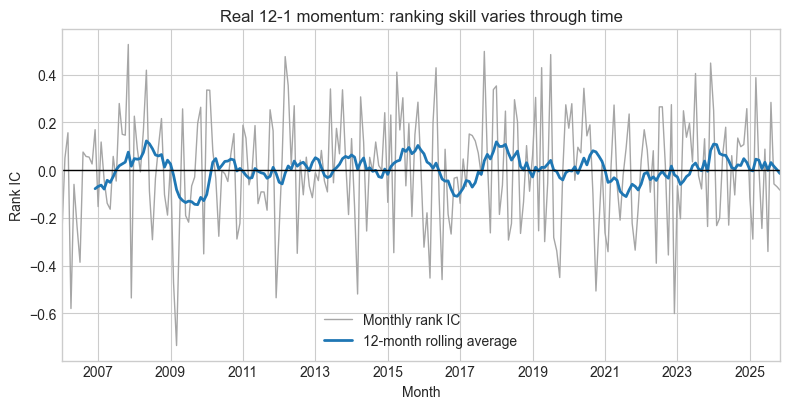

In [19]:
fig, ax = plt.subplots(figsize=(8, 4.2))
monthly_ic.plot(ax=ax, color="0.65", linewidth=1, label="Monthly rank IC")
monthly_ic.rolling(12).mean().plot(
    ax=ax,
    color="#1f77b4",
    linewidth=2,
    label="12-month rolling average",
)
ax.axhline(0, color="black", linewidth=1)
ax.set(
    title="Real 12-1 momentum: ranking skill varies through time",
    xlabel="Month",
    ylabel="Rank IC",
)
ax.legend()
fig.tight_layout()
plt.show()


Monthly IC swings from strongly positive to strongly negative. Its 12-month average crosses zero repeatedly. The chart confirms the table's result: no stable ranking relationship survives across the sample.


### From IC to Portfolio

We buy the top fifth, short the bottom fifth, assign 50% gross exposure to each side, and rebalance monthly. Gross exposure is the sum of absolute weights; net exposure is the signed sum. A basis point is 0.01%, so the simple cost model charges 0.05% per unit of one-way turnover.

Chapter 9 ranks stocks before applying its liquidity screen, which can leave fewer holdings than intended. The investable universe should be fixed first, using information available at the rebalance time, and the signal should be ranked inside that universe. Our price file has no point-in-time volume history. We therefore test the ranking and portfolio arithmetic without making a capacity claim.


In [20]:
# Hold the top and bottom fifth with 50% gross exposure on each side.
ranked_scores = scores.rank(axis=1, pct=True)
long_names = ranked_scores.ge(0.80)
short_names = ranked_scores.le(0.20)

long_weights = long_names.mul(0.5).div(long_names.sum(axis=1), axis=0)
short_weights = short_names.mul(-0.5).div(short_names.sum(axis=1), axis=0)
portfolio_weights = (long_weights + short_weights).fillna(0)

assert np.allclose(portfolio_weights.sum(axis=1), 0, atol=1e-12)
assert np.allclose(portfolio_weights.abs().sum(axis=1), 1, atol=1e-12)

# Apply next-month returns, then charge 5 bps per unit of one-way turnover.
gross_returns = portfolio_weights.mul(forward_returns).sum(axis=1)
position_change = portfolio_weights.diff()
position_change.iloc[0] = portfolio_weights.iloc[0]
one_way_turnover = position_change.abs().sum(axis=1) / 2
net_returns = gross_returns - one_way_turnover * 0.0005

assert np.isclose(one_way_turnover.iloc[0], 0.5)

construction_check = pd.Series(
    {
        "average long names": long_names.sum(axis=1).mean(),
        "average short names": short_names.sum(axis=1).mean(),
        "average gross exposure": portfolio_weights.abs().sum(axis=1).mean(),
        "average net exposure": portfolio_weights.sum(axis=1).mean(),
        "average one-way turnover": one_way_turnover.mean(),
    }
)
print(construction_check.round(3).to_string())


average long names          23.000
average short names         22.000
average gross exposure       1.000
average net exposure        -0.000
average one-way turnover     0.243


The portfolio holds about 22 stocks on each side, carries 100% gross exposure, and stays close to market neutral by construction. It replaces about 24% of one side each month. These quantities turn a ranking statistic into positions that can be priced. The row dated t uses information through t-1; its weights are applied to the return from t to t+1.


### Factor Attribution

Subtracting SPY from a portfolio produces an active-return series. Fama-French attribution uses a regression:

$$R_{p,t}-R_{f,t}=\alpha+\beta_M(MKT_t-R_{f,t})+\beta_S\,SMB_t+\beta_H\,HML_t+\varepsilon_t.$$

$R_p$ is portfolio return, $R_f$ is the risk-free return, SMB is the small-minus-big factor, and HML is the high-minus-low book-to-market factor. The intercept $\alpha$ is the average return left after these controls. Chapter 7 subtracts SPY and then regresses on SMB and HML without a complete market specification. That can't identify the three-factor exposures it describes.


In [21]:
factor_lines = FACTOR_FILE.read_text(encoding="utf-8").splitlines()
header_row = next(index for index, line in enumerate(factor_lines) if line.startswith(",Mkt-RF"))
monthly_rows = [
    line for line in factor_lines[header_row + 1 :] if len(line.split(",", 1)[0].strip()) == 6 and line.split(",", 1)[0].strip().isdigit()
]
factor_returns = pd.read_csv(io.StringIO("\n".join([factor_lines[header_row], *monthly_rows])))
factor_returns = factor_returns.rename(columns={factor_returns.columns[0]: "month"})
factor_returns["month"] = pd.to_datetime(factor_returns["month"].astype(str), format="%Y%m") + pd.offsets.MonthEnd(0)
factor_returns = factor_returns.set_index("month").astype(float) / 100
factor_returns = factor_returns.rename(columns={"Mkt-RF": "MKT_RF"})

print(f"Factor months: {factor_returns.index.min():%Y-%m} to {factor_returns.index.max():%Y-%m}")
print(factor_returns[["MKT_RF", "SMB", "HML", "RF"]].head(3).round(4).to_string())


Factor months: 1926-07 to 2026-06
            MKT_RF     SMB     HML      RF
month                                     
1926-07-31  0.0289 -0.0255 -0.0239  0.0022
1926-08-31  0.0264 -0.0114  0.0381  0.0025
1926-09-30  0.0038 -0.0136  0.0005  0.0023


The factor file contains monthly market, size, value, and risk-free returns. These are real observations from Kenneth French's Data Library. The regression aligns them by month with the momentum portfolio before estimating exposures.


In [22]:
# A score dated t earns the return from t to t+1. Move that return to t+1
# before matching it with the market, size, and value returns from the same month.
realized_net_returns = net_returns.copy()
realized_net_returns.index = realized_net_returns.index + pd.offsets.MonthEnd(1)

regression_data = pd.concat(
    [realized_net_returns.rename("portfolio"), factor_returns],
    axis=1,
    join="inner",
).dropna()
portfolio_excess_return = regression_data["portfolio"] - regression_data["RF"]
factor_design = sm.add_constant(regression_data[["MKT_RF", "SMB", "HML"]])
factor_model = sm.OLS(portfolio_excess_return, factor_design).fit()

portfolio_summary = pd.DataFrame(
    {
        "estimate": [
            gross_returns.mean(),
            net_returns.mean(),
            one_way_turnover.mean(),
            factor_model.params["const"],
            factor_model.params["MKT_RF"],
            factor_model.params["SMB"],
            factor_model.params["HML"],
        ],
        "meaning": [
            "Average monthly return before the simple cost model",
            "Average monthly return after 5 bps per unit of one-way turnover",
            "Average fraction of one side of the book replaced each month",
            "Monthly intercept left after the three factor controls",
            "Sensitivity to the market excess return",
            "Positive means a tilt toward smaller companies",
            "Positive means a tilt toward value companies",
        ],
    },
    index=[
        "gross return",
        "net return",
        "one-way turnover",
        "FF3 alpha",
        "market beta",
        "SMB beta",
        "HML beta",
    ],
)
print(portfolio_summary.round(6).to_string())


                  estimate                                                          meaning
gross return     -0.000436              Average monthly return before the simple cost model
net return       -0.000557  Average monthly return after 5 bps per unit of one-way turnover
one-way turnover  0.242641     Average fraction of one side of the book replaced each month
FF3 alpha        -0.001079           Monthly intercept left after the three factor controls
market beta      -0.136715                          Sensitivity to the market excess return
SMB beta         -0.065381                   Positive means a tilt toward smaller companies
HML beta         -0.282336                     Positive means a tilt toward value companies


After aligning each portfolio return with the month in which it was earned, the strategy loses 0.044% per month before the simple cost model and 0.056% afterward. Its market beta is -0.137, so the portfolio tended to move slightly against the market in this sample. The negative SMB and HML coefficients indicate large-company and growth tilts.

The factor-adjusted intercept is -0.108% per month. It differs from the raw mean because the regression removes returns associated with the estimated factor exposures.

These coefficients remain descriptive. An alpha claim also needs dependence-aware standard errors. The cost model omits borrow fees, spreads, market impact, and capacity, so it remains optimistic. Chapter 10's IC diagnostics are useful, but this implementation has not produced an investable momentum result.


A monthly Fama-MacBeth regression answers a related question. Imagine ranking 100 stocks on momentum every month while also recording their size. We regress next month's returns on momentum and size separately in each month. The resulting series of monthly momentum slopes shows whether momentum contributes information after controlling for size. Its uncertainty is then measured across months, just as we did with monthly IC.

IC, turnover, exposure, factor loadings, and portfolio return answer different questions. Chapter 7's pooled Spearman example shows why panel dependence matters. Chapter 10 improves the structure by calculating IC separately for each date with Alphalens and then examining the resulting time series. Its remaining weakness is interpretive rather than structural: generic statements such as IC 0.05 being "good" or 0.10 "excellent" need context around horizon, universe, turnover, stability, costs, and uncertainty.

Chapter 8 introduces a new problem: the researcher no longer tests one frozen signal. The code searches hundreds of parameter combinations and selects a winner.


## Selection Bias

Chapter 8 uses the free VectorBT package for its moving-average backtest and walk-forward optimization. Its workflow is the point of the chapter: VectorBT generates vectorized signals, broadcasts parameter combinations, simulates portfolios quickly, and supplies portfolio and trade metrics. The walk-forward recipe creates 30 rolling windows of 730 daily observations, reserves 180 observations in each window for testing, and evaluates moving-average pairs with fast and slow windows from 10 through 39. That leaves 435 combinations in every training window. The pair with the highest in-sample Sharpe is then measured on that split's later rows.

We first execute the book's moving-average flow on AAPL with the free package. A 0.1% fee is charged on each order so the cost assumption stays visible.


In [23]:
%%capture
%pip install vectorbt==1.1.0 --no-deps


In [24]:
import vectorbt as vbt


VECTORBT_PRICE_URL = "https://raw.githubusercontent.com/plotly/datasets/6a88de1c9a95f0019566d3b568eb26444feda686/finance-charts-apple.csv"
VECTORBT_PRICE_FILE = DATA_DIRECTORY / "vectorbt_aapl_daily.csv"

if not VECTORBT_PRICE_FILE.exists():
    pd.read_csv(VECTORBT_PRICE_URL).to_csv(VECTORBT_PRICE_FILE, index=False)

vectorbt_prices = pd.read_csv(
    VECTORBT_PRICE_FILE,
    index_col="Date",
    parse_dates=True,
)["AAPL.Adjusted"].rename("AAPL")

fast_ma = vbt.MA.run(vectorbt_prices, 10, short_name="fast")
slow_ma = vbt.MA.run(vectorbt_prices, 30, short_name="slow")

entries = fast_ma.ma_crossed_above(slow_ma)
exits = fast_ma.ma_crossed_below(slow_ma)

vectorbt_pf = vbt.Portfolio.from_signals(
    vectorbt_prices,
    entries,
    exits,
    fees=0.001,
    freq="1d",
)
vectorbt_holding_pf = vbt.Portfolio.from_holding(
    vectorbt_prices,
    fees=0.001,
    freq="1d",
)

vectorbt_summary = pd.Series(
    {
        "moving_average_total_return": vectorbt_pf.total_return(),
        "moving_average_sharpe": vectorbt_pf.sharpe_ratio(),
        "moving_average_trades": vectorbt_pf.trades.count(),
        "buy_and_hold_total_return": vectorbt_holding_pf.total_return(),
        "fee_per_order": 0.001,
    }
)

print(f"vectorbt {vbt.__version__}")
print(f"Daily prices: {len(vectorbt_prices):,}")
print(vectorbt_summary.round(4).to_string())


vectorbt 1.1.0
Daily prices: 506
moving_average_total_return     0.1686
moving_average_sharpe           0.7432
moving_average_trades          11.0000
buy_and_hold_total_return       0.1002
fee_per_order                   0.0010


The executable example now uses VectorBT's own indicator and portfolio APIs. `vbt.MA.run` produces the fast and slow moving averages, the indicator methods generate crossover signals, and `vbt.Portfolio.from_signals` performs the simulation. The portfolio object supplies total return, Sharpe ratio, and trade counts; `from_holding` supplies the benchmark on the same prices and cost convention.

The book correctly uses VectorBT again for parameter sweeps and rolling out-of-sample testing. The statistical comparison in that recipe is weaker: its rolling windows overlap heavily, and an independent-samples t-test compares selected in-sample Sharpes with held-out Sharpes. A negative t-statistic says the held-out mean is below the selected in-sample mean; it does not imply that the held-out return itself is negative.

Selection creates the larger statistical problem. Once we inspect 435 estimated Sharpes and retain the largest, the winner contains both any genuine edge and the luckiest sampling error. The simulation below isolates that mechanism by giving every candidate a true expected return of zero, selecting the best in-sample candidate, and applying it to fresh returns.

The book's SuperTrend recipe is a separate VectorBT Pro workflow. It imports `vectorbtpro`, builds a custom indicator with Pro's indicator factory, and sends its signals to `vbt.Portfolio.from_signals`. We source-reviewed that recipe but do not execute it here because Pro requires paid repository access. The free package is sufficient for the moving-average and walk-forward examples below.


In [25]:
def annualized_sharpe(return_matrix, periods_per_year):
    return np.sqrt(periods_per_year) * return_matrix.mean(axis=0) / return_matrix.std(axis=0, ddof=1)


# Every candidate is pure noise; only the selection procedure creates a winner.
number_of_experiments = 400
number_of_candidates = 435
days_per_sample = 504
selected_results = []

for _ in range(number_of_experiments):
    in_sample = rng.normal(0, 0.01, (days_per_sample, number_of_candidates))
    fresh_sample = rng.normal(0, 0.01, (days_per_sample, number_of_candidates))

    in_sample_sharpes = annualized_sharpe(in_sample, periods_per_year=252)
    # Select in sample, then evaluate the same candidate on fresh noise.
    winner = np.argmax(in_sample_sharpes)

    selected_results.append(
        {
            "best_in_sample_sharpe": in_sample_sharpes[winner],
            "same_candidate_fresh_sharpe": annualized_sharpe(fresh_sample, periods_per_year=252)[winner],
        }
    )

selection_results = pd.DataFrame(selected_results)
selection_summary = selection_results.agg(["mean", "median", "std"])

assert selection_results["best_in_sample_sharpe"].mean() > 1.5
print(selection_summary.round(3).to_string())


        best_in_sample_sharpe  same_candidate_fresh_sharpe
mean                    2.116                       -0.013
median                  2.075                        0.039
std                     0.284                        0.705


Selection alone produces an average winning in-sample Sharpe of 2.12. The same selected rules average -0.01 on fresh noise. A heatmap winner inherits the search even when every underlying candidate has zero edge.


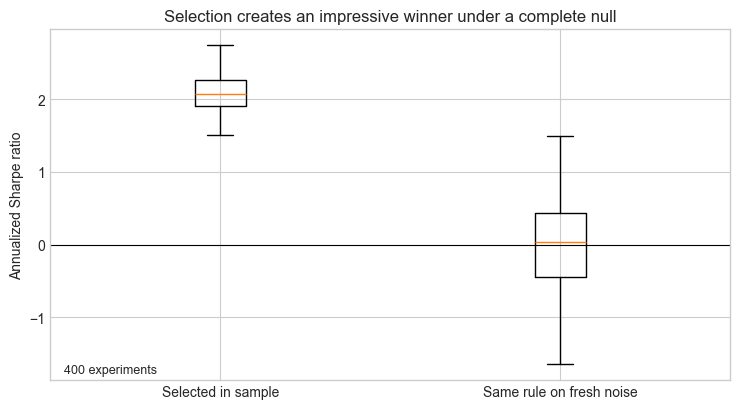

In [26]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.boxplot(
    [
        selection_results["best_in_sample_sharpe"],
        selection_results["same_candidate_fresh_sharpe"],
    ],
    showfliers=False,
)
ax.set_xticks([1, 2])
ax.set_xticklabels(["Selected in sample", "Same rule on fresh noise"])
ax.axhline(0, color="black", linewidth=0.8)
ax.set(
    title="Selection creates an impressive winner under a complete null",
    ylabel="Annualized Sharpe ratio",
)
ax.text(
    0.02,
    0.02,
    "400 experiments",
    transform=ax.transAxes,
    fontsize=9,
)
fig.tight_layout()
plt.show()


The distributions barely overlap. Correlated moving-average rules would reduce the effective number of independent trials, though the selection bias remains. The simulation illustrates the mechanism; it isn't a calibrated null for the book's exact grid.


### Walk-forward selection

Our repair follows the book's free-VectorBT structure on the same pinned daily AAPL series. `rolling_split` preserves chronological in-sample and out-of-sample blocks. `vbt.MA.run_combs` broadcasts all 435 moving-average pairs through every training split, and `vbt.Portfolio.from_signals` scores them with a visible 0.1% fee per order. Only the training Sharpe selects each pair. The frozen pair is then run on that split's later 90-day block.

We use 10 evenly spaced rolling windows rather than 30 to keep this article's full rerun modest. The windows still overlap, so their results are diagnostics rather than independent replications, and we do not stitch them into one return series.


In [27]:
(in_price, in_indexes), (out_price, out_indexes) = vectorbt_prices.vbt.rolling_split(
    n=10,
    window_len=360,
    set_lens=(90,),
    left_to_right=False,
)


def simulate_all_params(price, windows, **portfolio_kwargs):
    fast_grid, slow_grid = vbt.MA.run_combs(
        price,
        windows,
        r=2,
        short_names=["fast", "slow"],
    )
    grid_entries = fast_grid.ma_crossed_above(slow_grid)
    grid_exits = fast_grid.ma_crossed_below(slow_grid)
    portfolio = vbt.Portfolio.from_signals(
        price,
        grid_entries,
        grid_exits,
        **portfolio_kwargs,
    )
    return portfolio.sharpe_ratio()


windows = np.arange(10, 40)
in_sample_sharpe = simulate_all_params(
    in_price,
    windows,
    direction="both",
    fees=0.001,
    freq="1d",
)

best_index = in_sample_sharpe[in_sample_sharpe.groupby("split_idx").idxmax()].index
best_fast_windows = best_index.get_level_values("fast_window").to_numpy()
best_slow_windows = best_index.get_level_values("slow_window").to_numpy()

out_fast_ma = vbt.MA.run(
    out_price,
    window=best_fast_windows,
    per_column=True,
)
out_slow_ma = vbt.MA.run(
    out_price,
    window=best_slow_windows,
    per_column=True,
)
out_test_pf = vbt.Portfolio.from_signals(
    out_price,
    out_fast_ma.ma_crossed_above(out_slow_ma),
    out_fast_ma.ma_crossed_below(out_slow_ma),
    direction="both",
    fees=0.001,
    freq="1d",
)

walk_forward_results = pd.DataFrame(
    {
        "fast_window": best_fast_windows,
        "slow_window": best_slow_windows,
        "in_sample_sharpe": in_sample_sharpe.loc[best_index].to_numpy(),
        "out_sample_sharpe": out_test_pf.sharpe_ratio().to_numpy(),
        "out_sample_total_return": out_test_pf.total_return().to_numpy(),
        "out_sample_trades": out_test_pf.trades.count().to_numpy(),
    },
    index=pd.Index(range(out_price.shape[1]), name="split_idx"),
)

assert np.all(best_fast_windows < best_slow_windows)
assert all(in_indexes[split_idx][-1] < out_indexes[split_idx][0] for split_idx in range(out_price.shape[1]))

print(f"Training rows per split: {len(in_price):,}")
print(f"Later test rows per split: {len(out_price):,}")
print(f"Parameter combinations per split: {len(windows) * (len(windows) - 1) // 2:,}")
print(f"Rolling splits: {out_price.shape[1]:,}")
print(walk_forward_results.round(3).to_string())


Training rows per split: 270
Later test rows per split: 90
Parameter combinations per split: 435
Rolling splits: 10
           fast_window  slow_window  in_sample_sharpe  out_sample_sharpe  out_sample_total_return  out_sample_trades
split_idx                                                                                                           
0                   26           29             1.806             -3.346                   -0.131                  3
1                   26           27             1.944              1.523                    0.070                  3
2                   19           23             1.233              0.914                    0.039                  2
3                   10           17             1.539             -0.315                   -0.024                  3
4                   10           17             1.668             -0.633                   -0.043                  5
5                   10           17             1.716            

Each rolling split uses 270 earlier daily observations for parameter selection and 90 later observations for measurement. VectorBT evaluates 435 fast-slow pairs per training split. The selected parameters vary across the windows, which is useful evidence about stability. The later block never enters parameter selection.


In [28]:
fixed_fast_ma = vbt.MA.run(out_price, 10)
fixed_slow_ma = vbt.MA.run(out_price, 30)
fixed_pf = vbt.Portfolio.from_signals(
    out_price,
    fixed_fast_ma.ma_crossed_above(fixed_slow_ma),
    fixed_fast_ma.ma_crossed_below(fixed_slow_ma),
    direction="both",
    fees=0.001,
    freq="1d",
)
holding_pf = vbt.Portfolio.from_holding(
    out_price,
    fees=0.001,
    freq="1d",
)

vectorbt_comparison = pd.DataFrame(
    {
        "mean_sharpe_across_splits": [
            out_test_pf.sharpe_ratio().mean(),
            fixed_pf.sharpe_ratio().mean(),
            holding_pf.sharpe_ratio().mean(),
        ],
        "mean_total_return_across_splits": [
            out_test_pf.total_return().mean(),
            fixed_pf.total_return().mean(),
            holding_pf.total_return().mean(),
        ],
        "mean_trades_across_splits": [
            out_test_pf.trades.count().mean(),
            fixed_pf.trades.count().mean(),
            holding_pf.trades.count().mean(),
        ],
    },
    index=[
        "walk-forward selected MA",
        "fixed 10/30 MA",
        "buy and hold",
    ],
)

print("VectorBT metrics on the same 10 later test blocks")
print("Fee per order: 0.10%")
print(vectorbt_comparison.round(3).to_string())


VectorBT metrics on the same 10 later test blocks
Fee per order: 0.10%
                          mean_sharpe_across_splits  mean_total_return_across_splits  mean_trades_across_splits
walk-forward selected MA                     -0.346                           -0.019                        4.1
fixed 10/30 MA                                0.416                            0.012                        2.4
buy and hold                                  1.776                            0.100                        1.0


Across the ten later blocks, the selected pairs average a Sharpe of -0.35 and a total return of -1.9%. The fixed 10/30 rule averages a Sharpe of 0.42 and a 1.2% return, while buy and hold averages a Sharpe of 1.78 and a 10.0% return.

Those returns are means of split-level results, not one compounded track record. The three VectorBT portfolio objects use the same 0.1% fee per order. Because the test blocks overlap, the table remains diagnostic rather than ten independent replications. VectorBT makes the sweep fast; it cannot remove selection bias or overlapping-sample dependence. The benchmark also matters: the optimized rule loses to the fixed rule and buy and hold in this sample.


The correction depends on the search:

* White's Reality Check asks whether the best rule beat the benchmark after searching the full family.
* Hansen's SPA asks whether any plausible candidate beat the benchmark without letting very poor rules dominate the comparison.
* The Deflated Sharpe Ratio asks whether the reported Sharpe remains unusual after selection and non-normal returns.

The candidate ledger must record every rule tried. A correction applied only to the final winner has no record of the search it needs to correct.


### Mean reversion

Chapter 9's main mean-reversion recipe is a cross-sectional stock strategy. For each stock, it compares the latest monthly return with that stock's recent history and converts the difference into a z-score. Zipline buys up to 50 stocks with the lowest scores, shorts up to 50 with the highest scores, rebalances weekly, and includes commission and slippage models. As an introduction to event-driven portfolio code, this is useful material.

The liquidity screen keeps the 100 stocks with the highest 30-day dollar volume, but it is applied after the long and short names have been selected. The book notes that this can leave far fewer than 50 positions on either side. Ranking within the liquid universe would preserve the intended portfolio breadth.

The chapter also discusses ADF tests, the Hurst exponent, and half-life. Those tools examine whether one spread moves around a stable level through time; the book's Zipline recipe ranks many stocks against one another at each date. The pairs example below is therefore an extension of the chapter, not a reproduction of its stock portfolio.

Suppose two related stocks become unusually far apart. A z-score tells us that today's gap is large relative to its own history. It does not tell us that the gap has a stable center. A random walk can look cheap and keep falling. The Engle-Granger test asks whether two non-stationary price series show evidence of a stable long-run relationship. The half-life estimates how quickly the fitted spread would move halfway back toward its mean.

We compare XOM-CVX, which has an economic relationship, with AAPL-DUK, which does not. For each pair, we use the training prices to estimate the hedge ratio with OLS, construct the spread, run the Engle-Granger test, and estimate its half-life. Later prices remain separate. A stationary fitted spread is necessary for this mean-reversion thesis, not sufficient for a tradable strategy. Cointegration supports a long-run equilibrium relationship; it does not prove profitability. Hedge-ratio stability, costs, borrow, execution, structural breaks, and out-of-sample behaviour still matter.


In [29]:
training_rows = 168


# Estimate each hedge ratio using only the training period.
def estimate_log_spread(first_ticker, second_ticker):
    first = np.log(prices[first_ticker])
    second = np.log(prices[second_ticker])
    first_train = first.iloc[:training_rows]
    second_train = second.iloc[:training_rows]
    model = sm.OLS(second_train, sm.add_constant(first_train)).fit()
    intercept = model.params.iloc[0]
    hedge_ratio = model.params.iloc[1]
    return second - intercept - hedge_ratio * first, hedge_ratio


def estimated_half_life(spread):
    delta = spread.diff().dropna()
    lagged = spread.shift(1).reindex(delta.index)
    model = sm.OLS(delta, sm.add_constant(lagged)).fit()
    speed = model.params.iloc[1]
    if speed >= 0:
        return np.nan
    return -np.log(2) / speed


energy_spread, energy_hedge_ratio = estimate_log_spread("XOM", "CVX")
absurd_spread, absurd_hedge_ratio = estimate_log_spread("AAPL", "DUK")

print(pd.Series({"XOM-CVX hedge ratio": energy_hedge_ratio, "AAPL-DUK hedge ratio": absurd_hedge_ratio}).round(3).to_string())


XOM-CVX hedge ratio     1.565
AAPL-DUK hedge ratio    0.355


Both hedge ratios use only the first 168 months. The ratio scales the first stock when forming the spread. It creates comparable residuals for testing; it doesn't prove that either spread returns to a stable mean.


In [30]:
def pair_cointegration_diagnostics(first_ticker, second_ticker, spread):
    first_train = np.log(prices[first_ticker]).iloc[:training_rows]
    second_train = np.log(prices[second_ticker]).iloc[:training_rows]
    test_statistic, p_value, critical_values = coint(
        second_train,
        first_train,
        trend="c",
        return_results=False,
    )
    return pd.Series(
        {
            "Engle-Granger statistic": test_statistic,
            "MacKinnon p-value": p_value,
            "1% critical value": critical_values[0],
            "5% critical value": critical_values[1],
            "10% critical value": critical_values[2],
            "half-life in months": estimated_half_life(spread.iloc[:training_rows]),
        }
    )


spread_diagnostics = pd.DataFrame(
    {
        "XOM-CVX": pair_cointegration_diagnostics("XOM", "CVX", energy_spread),
        "AAPL-DUK": pair_cointegration_diagnostics("AAPL", "DUK", absurd_spread),
    }
).T

print(spread_diagnostics.round(3).to_string())


          Engle-Granger statistic  MacKinnon p-value  1% critical value  5% critical value  10% critical value  half-life in months
XOM-CVX                    -2.225              0.412             -3.963             -3.373               -3.07                9.659
AAPL-DUK                   -2.638              0.223             -3.963             -3.373               -3.07                8.261


Neither pair rejects the Engle-Granger null of no cointegration at 5%. XOM-CVX has a MacKinnon p-value of 0.412 and an estimated half-life of 9.7 months; AAPL-DUK has a p-value of 0.223 and a half-life of 8.3 months. Those half-lives are conditional summaries, not evidence that either spread has a stable equilibrium. Under the stated rule, neither pair qualifies for a z-score trade.


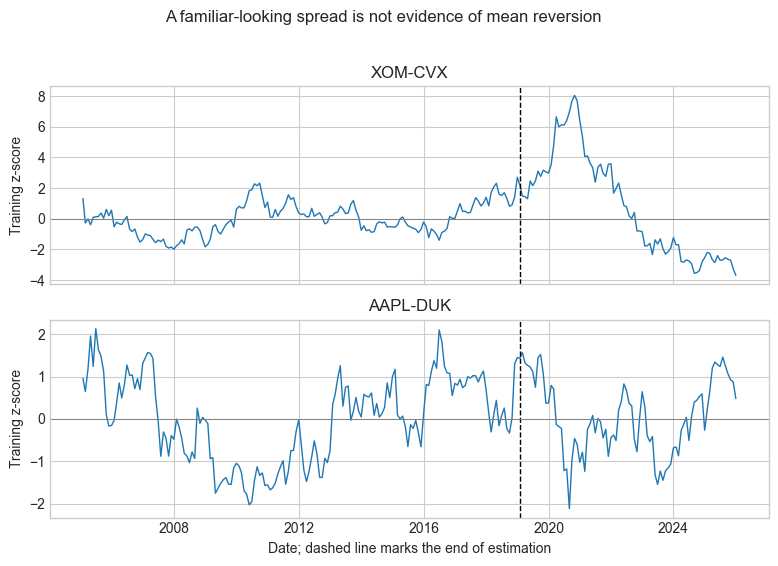

In [31]:
fig, axes = plt.subplots(2, 1, figsize=(8, 5.5), sharex=True)
for axis, spread, title in [
    (axes[0], energy_spread, "XOM-CVX"),
    (axes[1], absurd_spread, "AAPL-DUK"),
]:
    training_mean = spread.iloc[:training_rows].mean()
    training_std = spread.iloc[:training_rows].std()
    standardized_spread = (spread - training_mean) / training_std
    axis.plot(standardized_spread.index, standardized_spread, linewidth=1)
    axis.axvline(prices.index[training_rows], color="black", linestyle="--", linewidth=1)
    axis.axhline(0, color="gray", linewidth=0.7)
    axis.set(title=title, ylabel="Training z-score")

axes[1].set_xlabel("Date; dashed line marks the end of estimation")
fig.suptitle("A familiar-looking spread is not evidence of mean reversion", y=1.02)
fig.tight_layout()
plt.show()


The dashed line ends the training period. XOM-CVX breaks sharply afterward despite its plausible relationship. AAPL-DUK continues oscillating despite its weak economic story. Neither visual pattern overturns the test. Chapter 9 needs both the statistical gate and the forward portfolio test before trading the z-score.


Chapters 10 and 11 are most useful after the return series has survived those design checks. Their drawdown, turnover, exposure, and tear-sheet tools help us understand a strategy that has already been constructed honestly.


## From Research to Live Capital

Chapters 12 and 13 build an Interactive Brokers application from `EClient` and `EWrapper`, then add contracts, orders, positions, target weights, portfolio values, and SQL storage. For a retail reader, this is useful orientation. The callbacks make the broker's asynchronous model concrete, and the examples show how a signal eventually becomes an order.

Chapter 14 joins those pieces into a portfolio monitor, an options trade, and a crack-spread strategy. This is also where the book needs its strongest corrections. Live capital requires a valid equity ledger, matching observation frequencies, consistent contract units, precise option definitions, and durable broker state.

### Account Equity and Returns

The portfolio monitor applies `pct_change()` to cumulative unrealized PnL. Unrealized PnL can cross zero and has no stable capital base, so its percentage change is not a portfolio return. Account equity provides the denominator.


In [32]:
marked_account = pd.DataFrame(
    {
        "cash": [100_000, 97_900, 97_900],
        "position_value": [0, 1_800, 900],
        "fees_paid": [0, 300, 0],
    }
)
marked_account["equity"] = marked_account["cash"] + marked_account["position_value"]
marked_account["return"] = marked_account["equity"].pct_change()

assert np.isclose(marked_account.loc[1, "equity"], 99_700)
print(marked_account.round(4).to_string(index=False))


  cash  position_value  fees_paid  equity  return
100000               0          0  100000     NaN
 97900            1800        300   99700  -0.003
 97900             900          0   98800  -0.009


The $300 fee leaves equity at $99,700 after the position opens. A later $900 mark-to-market loss reduces equity to $98,800, a return of about -0.90%. The calculation reconciles cash, positions, fees, and capital. Percentage changes in cumulative PnL cannot do that.

### Sharpe and Time

Chapter 14 streams PnL every five seconds but annualizes volatility with $\sqrt{252}$, the daily factor. Its Sharpe expression also subtracts the annual risk-free rate at the wrong frequency and divides by volatility twice. We first match returns and the risk-free rate at one frequency, then annualize once.


In [33]:
annualization_factors = pd.Series(
    {
        "daily": np.sqrt(252),
        "five_second_RTH_IID": np.sqrt(252 * 6.5 * 60 * 60 / 5),
    }
)

spy_with_rf = pd.concat([spy_returns.rename("SPY"), factor_returns["RF"]], axis=1).dropna()
monthly_excess_return = spy_with_rf["SPY"] - spy_with_rf["RF"]
monthly_sharpe = np.sqrt(12) * monthly_excess_return.mean() / monthly_excess_return.std(ddof=1)

print(annualization_factors.round(3).to_string())
print()
print(f"Matched monthly observations: {len(monthly_excess_return)}")
print(f"SPY Sharpe using monthly returns and monthly RF: {monthly_sharpe:.3f}")


daily                    15.875
five_second_RTH_IID    1085.983

Matched monthly observations: 251
SPY Sharpe using monthly returns and monthly RF: 0.655


C:\Users\adamd\AppData\Local\Temp\ipykernel_3680\933140820.py:8: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  spy_with_rf = pd.concat([spy_returns.rename("SPY"), factor_returns["RF"]], axis=1).dropna()


The daily square-root factor is 15.875. Under a simple regular-session IID clock, the five-second factor is 1,085.983. That large gap exposes the frequency error; it does not make high-frequency Sharpe reliable. Intraday seasonality, serial dependence, auctions, and overnight exposure still need separate treatment. The monthly example avoids that ambiguity by matching real monthly SPY returns with a monthly risk-free rate.

### Crack Spread Units

Crude oil is quoted in dollars per barrel. RBOB gasoline and heating oil are quoted in dollars per gallon. Chapter 14 calculates `HO + 2*RB - 3*CL`, which subtracts incompatible units. A 3:2:1 crack converts the refined products using 42 gallons per barrel:

$$
\text{crack per barrel}=\frac{42(HO+2RB)-3CL}{3}.
$$


In [34]:
heating_oil_per_gallon = 2.20
gasoline_per_gallon = 2.05
crude_oil_per_barrel = 76.00

mixed_unit_result = heating_oil_per_gallon + 2 * gasoline_per_gallon - 3 * crude_oil_per_barrel
crack_per_barrel = (42 * (heating_oil_per_gallon + 2 * gasoline_per_gallon) - 3 * crude_oil_per_barrel) / 3

print(
    pd.Series(
        {
            "book expression, mixed units": mixed_unit_result,
            "correct 3:2:1 margin per barrel": crack_per_barrel,
        }
    )
    .round(2)
    .to_string()
)


book expression, mixed units      -221.7
correct 3:2:1 margin per barrel     12.2


The book's expression produces -221.70, which has no coherent unit. The corrected example produces a gross refining margin of $12.20 per barrel. A tradable implementation would still need aligned expiries, contract multipliers, rolls, margin, liquidity, and execution costs.

### Straddles and Strangles - Not the Same


The options recipe buys a call and put with the same $260 strike, which defines a straddle, while parts of the recipe call it a strangle. A strangle uses different strikes. 

The payoff table shows the difference.


In [35]:
terminal_prices = pd.Series([220, 240, 260, 280, 300], name="terminal_price")

option_payoffs = pd.DataFrame({"terminal_price": terminal_prices})
option_payoffs["straddle_K260_premium30"] = np.maximum(terminal_prices - 260, 0) + np.maximum(260 - terminal_prices, 0) - 30
option_payoffs["strangle_K240_280_premium15"] = np.maximum(terminal_prices - 280, 0) + np.maximum(240 - terminal_prices, 0) - 15

print(option_payoffs.to_string(index=False))


 terminal_price  straddle_K260_premium30  strangle_K240_280_premium15
            220                       10                            5
            240                      -10                          -15
            260                      -30                          -15
            280                      -10                          -15
            300                       10                            5


The straddle has one central strike and breaks even at $230 and $290. The strangle has a flat loss region between $240 and $280, with breakevens at $225 and $295. These are terminal payoffs before fees. A volatility trade also needs an implied-versus-realized volatility thesis, liquidity, margin, hedging, and exit rules.

### Broker Callbacks and Durable States

The broker chapters use fixed sleeps and shared mutable state to wait for asynchronous responses. 

A fixed delay tells us that time passed; it does not tell us that a particular request completed. The client also needs to survive duplicate callbacks and reconnects without counting the same fill twice.

Let's visualize it in this code:

In [36]:
allowed_transitions = {
    "risk_checked": {"submitted", "rejected"},
    "submitted": {"acknowledged", "partially_filled", "filled", "rejected"},
    "acknowledged": {"partially_filled", "filled", "canceled", "rejected"},
    "partially_filled": {"partially_filled", "filled", "canceled"},
}

broker_events = [
    ("risk_checked", 0, None),
    ("submitted", 0, None),
    ("acknowledged", 0, None),
    ("partially_filled", 40, "E1"),
    ("partially_filled", 40, "E1"),
    ("filled", 60, "E2"),
]

seen_executions = set()
filled_quantity = 0
previous_state = None
accepted_events = []

for state, new_fill, execution_id in broker_events:
    if execution_id is not None and execution_id in seen_executions:
        continue
    if previous_state is not None:
        assert state in allowed_transitions[previous_state]
    if execution_id is not None:
        seen_executions.add(execution_id)
    filled_quantity += new_fill
    accepted_events.append((state, new_fill, execution_id, filled_quantity))
    previous_state = state

order_ledger = pd.DataFrame(
    accepted_events,
    columns=["state", "new_fill", "execution_id", "cumulative_fill"],
)

assert filled_quantity == 100
assert previous_state == "filled"
print(order_ledger.to_string(index=False))


           state  new_fill execution_id  cumulative_fill
    risk_checked         0          NaN                0
       submitted         0          NaN                0
    acknowledged         0          NaN                0
partially_filled        40           E1               40
          filled        60           E2              100


Execution `E1` arrives twice, but the ledger counts its 40 shares once. Execution `E2` supplies the remaining 60, leaving a final fill of 100 shares. This is the minimum idea behind idempotence. A production client also needs request-specific completion events, full contract identity, order-ID reconciliation, timeouts, reconnect handling, stale-data controls, and a kill switch.

Chapters 12 and 13 teach the broker vocabulary and callback flow well. Chapter 14 shows how those parts connect to a live strategy. We would treat the code as an API orientation, not a production architecture, until the accounting, units, and state controls above are added.


Chapter 16 gathers the workflow and tools into a useful closing reference. It adds little new evidence, but it helps a reader find the relevant recipe when building a project.


# Conclusion

Overall, the book succeeds as a broad and practical introduction to the modern Python quant stack. We would recommend it to retail or independent researchers who want to develop research fluency through hands-on implementation.

The main limitation is that several strategy results rely on in-sample evidence or invalid inference, so we should treat them as implementation exercises rather than evidence of genuine alpha. The live-trading chapters also need corrected accounting, contract units, and broker state before controlling capital.

We would use the book to learn the tools and reproduce the mechanics, then strengthen its timing, inference, search accounting, costs, portfolio construction, and execution controls. For its intended audience, it remains a useful and worthwhile book.


## References

1. Strimpel, J. (2026). [*Python for Algorithmic Trading Cookbook, Second Edition*](https://www.packtpub.com/en-us/product/python-for-algorithmic-trading-cookbook-9781806662036). Packt.
2. Fama, E. F., and MacBeth, J. D. (1973). *Risk, Return, and Equilibrium: Empirical Tests*. https://doi.org/10.1086/260061
3. Fama, E. F., and French, K. R. (1993). *Common Risk Factors in the Returns on Stocks and Bonds*. https://doi.org/10.1016/0304-405X(93)90023-5
4. Newey, W. K., and West, K. D. (1987). *A Simple, Positive Semi-Definite, Heteroskedasticity and Autocorrelation Consistent Covariance Matrix*. https://www.jstor.org/stable/1913610
5. White, H. (2000). *A Reality Check for Data Snooping*. https://doi.org/10.1111/1468-0262.00152
6. Hansen, P. R. (2005). *A Test for Superior Predictive Ability*. https://doi.org/10.1198/073500105000000063
7. Bailey, D. H., and López de Prado, M. (2014). *The Deflated Sharpe Ratio*. https://doi.org/10.3905/jpm.2014.40.5.094
8. Lo, A. W. (2002). *The Statistics of Sharpe Ratios*. https://doi.org/10.2469/faj.v58.n4.2453
9. Scikit-learn. *PCA*. https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html
10. ArcticDB. *Documentation*. https://docs.arcticdb.io/latest/
11. HerdingAI. *Stock Price Returns*. https://github.com/HerdingAI/stock-price-returns/tree/e58de84b37a85d6c0fb95cad4f52146fc4f0cb97
12. Kenneth R. French. *Data Library*. https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html
13. CME Group. *An Introduction to Crack Spreads*. https://www.cmegroup.com/articles/whitepapers/an-introduction-to-crack-spreads.html
14. Interactive Brokers. *TWS API Documentation*. https://www.interactivebrokers.com/campus/ibkr-api-page/twsapi-doc/


## Github

Article here is also available on [Github](https://github.com/adamd1985/quant_research/blob/main/algorithmic_trading_cookbook_review.ipynb)

Kaggle notebook available [here](https://www.kaggle.com/code/addarm/algorithmic_trading_cookbook_review)


## Media

All media used (in the form of code or images) are either solely owned by me, acquired through licensing, or part of the Public Domain and granted use through Creative Commons License.

## CC Licensing and Use

<a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/">Creative Commons Attribution-NonCommercial 4.0 International License</a>.